--- Step 3.1: Loading Dataset from iris.csv ---

--- Step 3.2: Exploring the Data ---
First 5 Rows:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Data Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None

Statistical Summary:
       sepal_

C:\Users\NITRO V\AppData\Local\Temp\ipykernel_26768\2378720890.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bar_x, y=bar_y, data=self.data, palette="viridis")


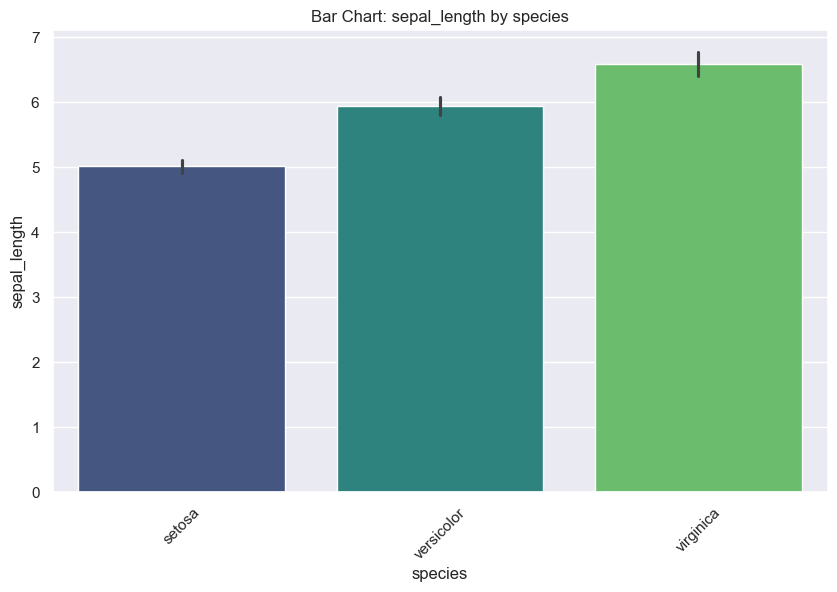

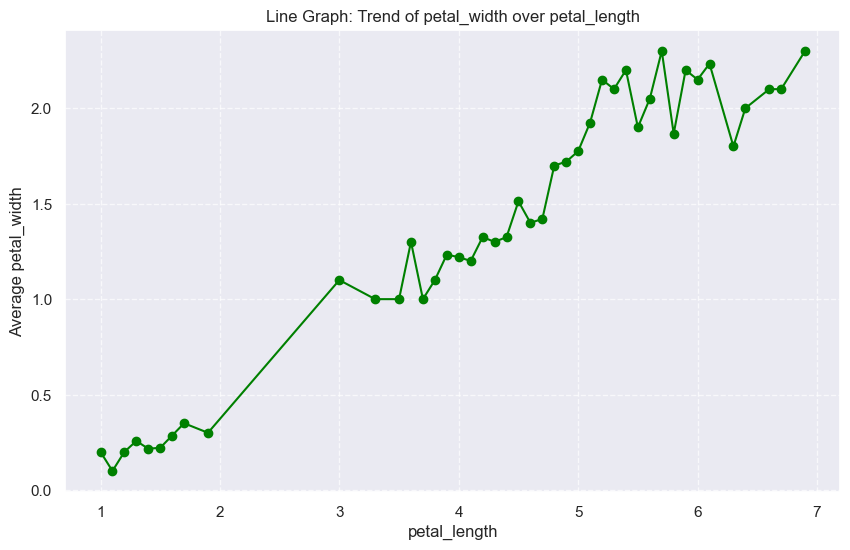

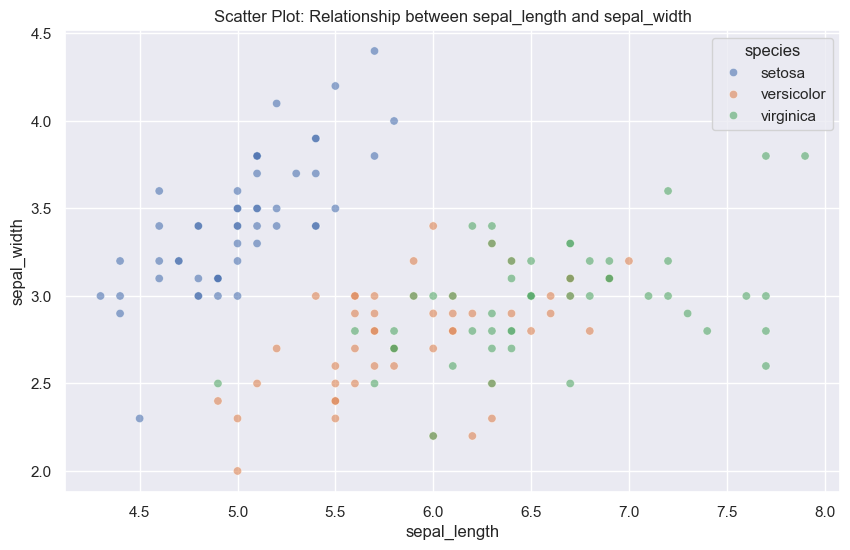

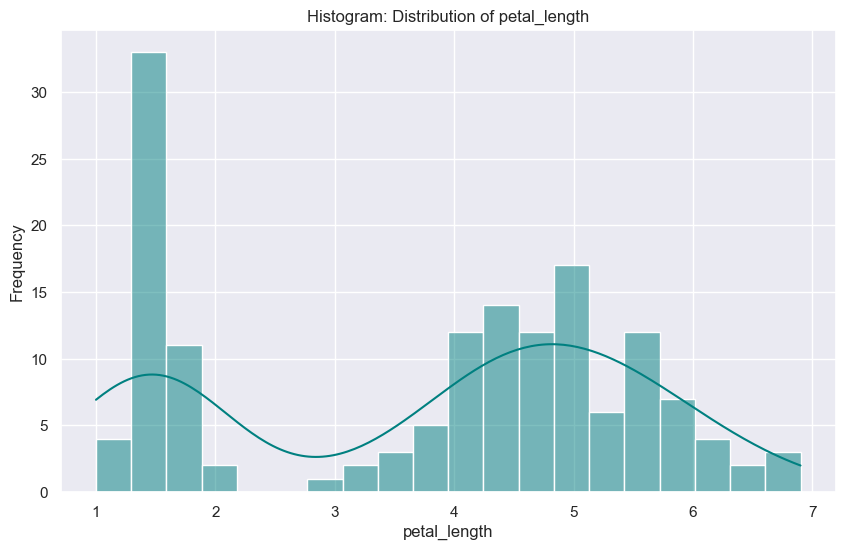

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

class DataVisualizationExperiment:
    """
    Generic implementation of Exp 10: Select Dataset and Apply Visualization Techniques.
    This script is designed to work with any CSV dataset by updating the CONFIG section.
    """

    def __init__(self, file_path):
        self.file_path = file_path
        self.data = None

    def step_3_data_preparation(self):
        """Step 3: Load, Explore, and Clean the Dataset."""
        print(f"--- Step 3.1: Loading Dataset from {self.file_path} ---")
        try:
            # Load the dataset
            self.data = pd.read_csv(self.file_path)
            
            # Explore the data
            print("\n--- Step 3.2: Exploring the Data ---")
            print("First 5 Rows:")
            print(self.data.head())
            print("\nData Information:")
            print(self.data.info())
            print("\nStatistical Summary:")
            print(self.data.describe())
            
            # Clean the data
            print("\n--- Step 3.3: Cleaning the Data ---")
            initial_count = len(self.data)
            self.data = self.data.dropna() # Removing rows with missing values
            print(f"Removed {initial_count - len(self.data)} rows with missing values.")
            print(f"Final dataset size: {self.data.shape}")
            return True
        except Exception as e:
            print(f"Error during preparation: {e}")
            return False

    def step_4_create_visualizations(self, config):
        """Step 4: Creating and Customizing Visualizations based on CONFIG."""
        print("\n--- Step 4: Creating Visualizations ---")
        sns.set_theme(style="darkgrid") # Setting up the aesthetic environment

        # 1. Bar Chart for Categorical Data
        bar_x = config.get('bar_x')
        bar_y = config.get('bar_y')
        if bar_x in self.data.columns and bar_y in self.data.columns:
            plt.figure(figsize=(10, 6))
            sns.barplot(x=bar_x, y=bar_y, data=self.data, palette="viridis")
            plt.title(f"Bar Chart: {bar_y} by {bar_x}")
            plt.xlabel(bar_x)
            plt.ylabel(bar_y)
            plt.xticks(rotation=45)
            plt.show()
        else:
            print(f"Skipping Bar Chart: Columns '{bar_x}' or '{bar_y}' not found.")

        # 2. Line Graph for Trends
        line_x = config.get('line_x')
        line_y = config.get('line_y')
        if line_x in self.data.columns and line_y in self.data.columns:
            plt.figure(figsize=(10, 6))
            # Sort by X-axis to ensure line plots represent a logical sequence
            sorted_data = self.data.sort_values(by=line_x)
            # Use aggregation (mean) if there are multiple Y values for one X
            trend_data = sorted_data.groupby(line_x)[line_y].mean().reset_index()
            plt.plot(trend_data[line_x], trend_data[line_y], marker='o', color='green', linestyle='-')
            plt.title(f"Line Graph: Trend of {line_y} over {line_x}")
            plt.xlabel(line_x)
            plt.ylabel(f"Average {line_y}")
            plt.grid(True, linestyle='--', alpha=0.7)
            plt.show()
        else:
            print(f"Skipping Line Graph: Columns '{line_x}' or '{line_y}' not found.")

        # 3. Scatter Plot for Relationships
        scat_x = config.get('scatter_x')
        scat_y = config.get('scatter_y')
        hue_col = config.get('scatter_hue') # Optional coloring by category
        if scat_x in self.data.columns and scat_y in self.data.columns:
            plt.figure(figsize=(10, 6))
            sns.scatterplot(x=scat_x, y=scat_y, data=self.data, hue=hue_col if hue_col in self.data.columns else None, alpha=0.6)
            plt.title(f"Scatter Plot: Relationship between {scat_x} and {scat_y}")
            plt.xlabel(scat_x)
            plt.ylabel(scat_y)
            plt.show()
        else:
            print(f"Skipping Scatter Plot: Columns '{scat_x}' or '{scat_y}' not found.")

        # 4. Histogram for Distribution
        hist_col = config.get('hist_col')
        if hist_col in self.data.columns:
            plt.figure(figsize=(10, 6))
            sns.histplot(self.data[hist_col], bins=20, kde=True, color="teal")
            plt.title(f"Histogram: Distribution of {hist_col}")
            plt.xlabel(hist_col)
            plt.ylabel("Frequency")
            plt.show()
        else:
            print(f"Skipping Histogram: Column '{hist_col}' not found.")

# --- CONFIGURATION SECTION ---
# Update these values to match your specific dataset columns.

CONFIG_IRIS = {
    "file_path": "iris.csv",
    "bar_x": "species",
    "bar_y": "sepal_length",
    "line_x": "petal_length",
    "line_y": "petal_width",
    "scatter_x": "sepal_length",
    "scatter_y": "sepal_width",
    "scatter_hue": "species",
    "hist_col": "petal_length"
}

if __name__ == "__main__":
    # SELECT YOUR CONFIG HERE
    active_config = CONFIG_IRIS 
    
    experiment = DataVisualizationExperiment(active_config['file_path'])
    
    if experiment.step_3_data_preparation():
        experiment.step_4_create_visualizations(active_config)